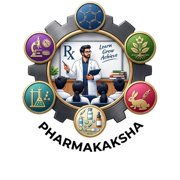

# BP201T · Unit IV — Basics of Correlation and Regression
**Pharmakaksha · Learn · Grow · Achieve**
*Applied Biostatistics and Data Analytics for Pharmaceutical Sciences · B.Pharm Semester II · PCI NEP 2020*

This notebook contains every example and demo from the Unit IV study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP201T_Unit4_Correlation_and_Regression.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP201T_Unit4_Correlation_and_Regression.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import scipy` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. The analyses are for learning statistics only. They are not clinical or regulatory decisions.

## 4.1 Scatter plots and correlation
**Correlation** measures how strongly two numerical variables move together. Always **plot first**: a scatter plot shows the direction, the strength, the shape (straight or curved) and any outliers.

`dose_response.csv` is a fictional dose-finding study: 36 patients received 10–60 mg of an antihypertensive (6 patients per dose) and their fall in SBP was measured.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

In [ ]:
from scipy import stats

dr = load("dose_response.csv")
print(dr.shape)
print(dr.groupby("dose_mg")["sbp_fall_mmHg"].mean().round(1))

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(dr["dose_mg"], dr["sbp_fall_mmHg"], color="#17725C", s=50, alpha=0.8)
plt.xlabel("Dose (mg)"); plt.ylabel("Fall in SBP (mmHg)")
plt.title("Dose–response: higher dose, bigger fall in SBP")
plt.grid(alpha=0.3); plt.show()

## 4.2 Pearson's correlation coefficient r
r = Σ(x − x̄)(y − ȳ) / √[Σ(x − x̄)² × Σ(y − ȳ)²]

- r runs from **−1** (perfect negative) through **0** (no straight-line relationship) to **+1** (perfect positive).
- A rough guide to strength: |r| < 0.3 weak, 0.3–0.7 moderate, > 0.7 strong.
- r measures only **linear** relationships, and it is sensitive to outliers.

In [ ]:
x, y = dr["dose_mg"], dr["sbp_fall_mmHg"]

# Step by step
dx, dy = x - x.mean(), y - y.mean()
r_manual = (dx * dy).sum() / np.sqrt((dx ** 2).sum() * (dy ** 2).sum())
print("r (by formula):", round(r_manual, 4))

# One line with NumPy, Pandas or SciPy
print("r (NumPy):     ", round(np.corrcoef(x, y)[0, 1], 4))
print("r (Pandas):    ", round(x.corr(y), 4))
r, p = stats.pearsonr(x, y)
print(f"r (SciPy):      {r:.4f},  p = {p:.2e}")

## 4.3 Positive and negative correlation
In **positive** correlation both variables rise together (dose and response). In **negative** correlation one rises as the other falls. In the PK study (`pk_volunteers.csv`), heavier volunteers had a **lower** AUC after the same fixed dose.

In [ ]:
pk = load("pk_volunteers.csv")
r_pk, p_pk = stats.pearsonr(pk["weight_kg"], pk["auc_ng_h_ml"])
print(f"Weight vs AUC: r = {r_pk:.2f}, p = {p_pk:.1e}")

rng = np.random.default_rng(5)
noise_x, noise_y = rng.normal(0, 1, 40), rng.normal(0, 1, 40)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].scatter(x, y, color="#17725C"); ax[0].set_title(f"Positive: r = {r:.2f}")
ax[0].set_xlabel("Dose (mg)"); ax[0].set_ylabel("Fall in SBP (mmHg)")
ax[1].scatter(pk["weight_kg"], pk["auc_ng_h_ml"], color="#E07A2E"); ax[1].set_title(f"Negative: r = {r_pk:.2f}")
ax[1].set_xlabel("Body weight (kg)"); ax[1].set_ylabel("AUC (ng·h/mL)")
ax[2].scatter(noise_x, noise_y, color="#12303A"); ax[2].set_title(f"None: r = {np.corrcoef(noise_x, noise_y)[0, 1]:.2f}")
ax[2].set_xlabel("Variable X"); ax[2].set_ylabel("Variable Y")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

> **Correlation is not causation.** Ice-cream sales and drowning deaths are correlated because both rise in summer. Only a randomised experiment, such as our dose-finding trial, shows that one variable *causes* the other.

## 4.4 Simple linear regression
Correlation says *how strongly* two variables are related. **Regression** gives the **equation** of the best straight line, so we can **predict** y from x:

**y = a + b·x**, where **b** (slope) = change in y for each 1-unit increase in x, and **a** (intercept) = predicted y when x = 0.

The **least-squares** line makes the sum of squared vertical distances (residuals) as small as possible: b = Σ(x − x̄)(y − ȳ) / Σ(x − x̄)², and a = ȳ − b·x̄.

In [ ]:
b = (dx * dy).sum() / (dx ** 2).sum()
a = y.mean() - b * x.mean()
print(f"By formula: slope b = {b:.4f}, intercept a = {a:.4f}")

fit = stats.linregress(x, y)
print(f"SciPy linregress: slope = {fit.slope:.4f}, intercept = {fit.intercept:.4f}")
print(f"r = {fit.rvalue:.4f}, R² = {fit.rvalue ** 2:.4f}, p = {fit.pvalue:.2e}, SE of slope = {fit.stderr:.4f}")

**Reading the coefficients:** each extra 1 mg of drug lowers SBP by about 0.28 mmHg more, so each 10 mg adds about 2.8 mmHg. **R²** (the coefficient of determination) = r² is the fraction of the variation in response explained by dose.

In [ ]:
for d in [25, 45]:
    print(f"Predicted fall at {d} mg: {fit.intercept + fit.slope * d:.1f} mmHg")

xs = np.linspace(5, 65, 50)
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="#17725C", s=50, alpha=0.8, label="Patients")
plt.plot(xs, fit.intercept + fit.slope * xs, color="#E07A2E", linewidth=2.5,
         label=f"y = {fit.intercept:.2f} + {fit.slope:.3f}x  (R² = {fit.rvalue ** 2:.2f})")
plt.xlabel("Dose (mg)"); plt.ylabel("Fall in SBP (mmHg)")
plt.title("Least-squares regression line"); plt.legend(); plt.grid(alpha=0.3); plt.show()

**Residuals** (observed − predicted) should scatter randomly around zero. A pattern (a curve, or a funnel) warns that a straight line is not the right model. And never **extrapolate** far beyond the doses studied (10–60 mg).

In [ ]:
pred = fit.intercept + fit.slope * x
resid = y - pred
print("Sum of residuals:", round(abs(resid.sum()), 6), "  SD of residuals:", round(resid.std(), 2))

plt.figure(figsize=(8, 3.8))
plt.scatter(pred, resid, color="#12303A")
plt.axhline(0, color="#E07A2E")
plt.xlabel("Predicted fall (mmHg)"); plt.ylabel("Residual (mmHg)")
plt.title("Residuals scatter randomly around zero: a straight line fits"); plt.grid(alpha=0.3); plt.show()

## 4.5 Odds ratio in clinical risk
For a **yes/no outcome** we compare risks with a 2 × 2 table. A case–control study asks whether NSAID use is linked to upper-GI bleeding: 200 patients with a GI bleed (cases) and 400 without (controls).

| | GI bleed (cases) | No bleed (controls) |
|---|---|---|
| **NSAID users** | a = 80 | b = 80 |
| **Non-users** | c = 120 | d = 320 |

**Odds** = events / non-events. **Odds ratio (OR) = (a/c) / (b/d) = ad / bc.** OR = 1 means no association; OR > 1 means higher odds with exposure; OR < 1 means lower odds (protective).

In [ ]:
a_, b_, c_, d_ = 80, 80, 120, 320
odds_ratio = (a_ * d_) / (b_ * c_)
se_log = np.sqrt(1 / a_ + 1 / b_ + 1 / c_ + 1 / d_)
lo, hi = np.exp(np.log(odds_ratio) - 1.96 * se_log), np.exp(np.log(odds_ratio) + 1.96 * se_log)
print(f"OR = {odds_ratio:.2f}, 95% CI {lo:.2f} to {hi:.2f}")

table = [[a_, b_], [c_, d_]]
print("Fisher's exact test:", stats.fisher_exact(table))
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"Chi-square = {chi2:.2f}, p = {p:.1e}")

The CI does not include 1, so the association is statistically significant. NSAID users had about **2.7 times the odds** of a GI bleed.

**Relative risk (RR)** is used in cohort studies and trials, where we follow exposed and unexposed people forward. In our trial, ADRs occurred in 17 of 60 drug patients and 3 of 60 placebo patients:

In [ ]:
bp = load("bp_trial.csv")
tab = pd.crosstab(bp["group"], bp["adr"])
print(tab)
risk_drug = tab.loc["Drug", "Yes"] / tab.loc["Drug"].sum()
risk_plac = tab.loc["Placebo", "Yes"] / tab.loc["Placebo"].sum()
print(f"Risk: drug {risk_drug:.3f}, placebo {risk_plac:.3f}")
print(f"Relative risk = {risk_drug / risk_plac:.2f}")
odds_d = tab.loc["Drug", "Yes"] / tab.loc["Drug", "No"]; odds_p = tab.loc["Placebo", "Yes"] / tab.loc["Placebo", "No"]
print(f"Odds ratio = {odds_d / odds_p:.2f}")

When the outcome is rare (< 10%), OR ≈ RR. When it is common, the OR is further from 1 than the RR, so do not read an OR as "times the risk".

## Worked example: dose–response report
Summarise the dose–response study in four lines.

In [ ]:
fit = stats.linregress(dr["dose_mg"], dr["sbp_fall_mmHg"])
ci_slope = stats.t.ppf(0.975, len(dr) - 2) * fit.stderr
print(f"n = {len(dr)} patients, doses 10–60 mg")
print(f"Pearson r = {fit.rvalue:.2f} (p < 0.001): strong positive correlation")
print(f"Fall in SBP = {fit.intercept:.2f} + {fit.slope:.3f} × dose;  slope 95% CI {fit.slope - ci_slope:.3f} to {fit.slope + ci_slope:.3f}")
print(f"Dose explains {100 * fit.rvalue ** 2:.0f}% of the variation in response (R²)")

## Quick check
Across 30 countries, chocolate consumption correlates with Nobel prizes (r = 0.79). Should a pharmacist recommend chocolate for brain power? Decide, then run the cell.

In [ ]:
print("No. Correlation is not causation: national wealth drives both (a confounder).")

## Try it yourself (lab)
**1.** Find Pearson r between `cmax_ng_ml` and `auc_ng_h_ml` in `pk_volunteers.csv`. Is it positive or negative?

**2.** Fit a regression of `week8_sbp` on `baseline_sbp` in `bp_trial.csv`. Interpret the slope.

**3.** Predict the fall in SBP at 35 mg from the dose–response line.

**4.** In a cohort, 30 of 200 smokers and 10 of 300 non-smokers developed a cough on an ACE inhibitor. Compute the RR and the OR.

---
## Solutions

In [ ]:
# 1
pk = load("pk_volunteers.csv")
print(stats.pearsonr(pk["cmax_ng_ml"], pk["auc_ng_h_ml"]))   # strong positive

In [ ]:
# 2
bp = load("bp_trial.csv")
f2 = stats.linregress(bp["baseline_sbp"], bp["week8_sbp"])
print(round(f2.slope, 3), round(f2.intercept, 1), round(f2.rvalue ** 2, 3))   # each 1 mmHg higher baseline -> ~0.8 mmHg higher at week 8

In [ ]:
# 3
print(round(fit.intercept + fit.slope * 35, 1), "mmHg")

In [ ]:
# 4
rr = (30 / 200) / (10 / 300); orr = (30 * 290) / (170 * 10)
print("RR =", round(rr, 2), " OR =", round(orr, 2))

---
**Next:** Unit V — Statistical Analysis Using Python (case-based). Pharmakaksha · Learn · Grow · Achieve